# EEG Low Frequency Deep Brain Stimulation (DBS) Pipeline
This pipeline is designed to process EEG data in the context of low frequency deep brain stimulation (DBS) studies. It includes steps for data preprocessing, artifact removal, and analysis of neural signals.

## Imports & Environment Setup

In [204]:
import os
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kurtosis
from mne.time_frequency import psd_array_welch
from typing import List, Optional, Tuple, Dict
import tqdm

# Set plotting aesthetics
sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.figsize': (15, 8),
    'font.size': 12,
    'figure.dpi': 150
})

print(f"MNE Version: {mne.__version__} | Environment ready.")

MNE Version: 1.11.0 | Environment ready.


## Helper Functions

In [205]:
def load_eeg_data(patient: str, dbs_freq: int, base_path: str) -> tuple:
    # Function to load EEG data based on patient ID, DBS frequency, and sleep state
    # Placeholder implementation
    file_path_sleep = f"{base_path}/{patient}/{patient}SLEEP{dbs_freq}.EDF"
    file_path_awake = f"{base_path}/{patient}/{patient}AWAKE{dbs_freq}.EDF"
    raw_sleep = mne.io.read_raw_edf(file_path_sleep, preload=True, verbose=False)
    raw_awake = mne.io.read_raw_edf(file_path_awake, preload=True, verbose=False)
    return raw_sleep, raw_awake

In [206]:
def print_eeg_info(raw):
    """Prints a formatted summary of the EEG recording."""
    info = raw.info
    subj = info['subject_info'] if info['subject_info'] else {'his_id': 'Unknown'}
    
    # Calculate durations
    total_seconds = raw.times[-1]
    mins, secs = divmod(total_seconds, 60)
    
    header = f" EEG SESSION: {subj.get('his_id', 'N/A')} "
    print(f"\n{header:=^60}")
    print(f"Sampling Rate: {info['sfreq']:.1f} Hz")
    print(f"Duration:      {int(mins)}m {int(secs)}s")
    print(f"Channels:      {info['nchan']} total")
    
    # Categorize for the user
    ch_types = raw.get_channel_types()
    unique_types = set(ch_types)
    for t in unique_types:
        count = ch_types.count(t)
        print(f"  - {t.upper()}: {count}")
    print("="*60)

In [207]:
def set_custom_channel_types(raw):
    """
    Optimized for your dataset: Maps EEG, EKG, EOG, EMG, and Bio-sensors.
    """
    # 1. Standardize mapping logic
    mapping = {}
    for ch in raw.ch_names:
        # EEG Channels (Standard + Extended T1/T2/Fpz)
        if ch in ['Fp1', 'F7', 'T3', 'T5', 'O1', 'F3', 'C3', 'P3', 'A1', 'Fz', 
                  'Cz', 'Fp2', 'F8', 'T4', 'T6', 'O2', 'F4', 'C4', 'P4', 'A2', 
                  'Fpz', 'Pz', 'T1', 'T2']:
            mapping[ch] = 'eeg'
        
        # Cardiac
        elif 'EKG' in ch or 'ECG' in ch or ch == 'PR':
            mapping[ch] = 'ecg'
            
        # Ocular (Eye movements)
        elif 'LOC' in ch or 'ROC' in ch or 'EOG' in ch:
            mapping[ch] = 'eog'
            
        # Muscle
        elif 'EMG' in ch:
            mapping[ch] = 'emg'
            
        # Oxygen Saturation (Specific to your OSAT channel)
        elif ch == 'OSAT':
            mapping[ch] = 'bio' # 'bio' is better than 'misc' for physiological data
            
        # DC Channels and X-auxiliaries
        elif ch.startswith('DC') or ch.startswith('X'):
            mapping[ch] = 'bio'
            
        else:
            mapping[ch] = 'misc'

    raw.set_channel_types(mapping)
    print(f"✅ Successfully mapped {len(mapping)} channels.")

In [208]:
def set_eeg_montage(raw, montage_name='standard_1020'):
    """
    Renames legacy T1/T2 labels to modern 10-10 equivalents 
    so they can be mapped to a standard montage.
    """
    # 1. Define the mapping for legacy clinical labels
    # T1/T2 are commonly used for anterior temporal electrodes
    rename_dict = {'T1': 'FT9', 'T2': 'FT10'}
    
    # 2. Filter dict to only include channels actually present in this raw file
    existing_renames = {old: new for old, new in rename_dict.items() if old in raw.ch_names}
    
    if existing_renames:
        raw.rename_channels(existing_renames)
        print(f"🔄 Renamed legacy channels: {existing_renames}")

    # 3. Apply the montage
    try:
        # standard_1020 doesn't always have FT9/FT10; 
        # 'standard_1005' is the superset that includes almost all positions
        montage = mne.channels.make_standard_montage('standard_1005')
        
        raw.set_montage(montage, on_missing='warn')
        print(f"✅ Montage applied using 10-05 coordinate system.")
    except Exception as e:
        print(f"❌ Montage Error: {e}")

In [209]:
def set_reference(raw, ref_channels='average'):
    """
    Sets EEG reference. If average, it only applies to EEG channels.
    """
    # Ensure we are only referencing EEG channels to avoid EKG/EMG contamination
    raw.set_eeg_reference(ref_channels=ref_channels, projection=False)
    print(f"✅ Re-referenced to: {ref_channels}")

In [210]:
def plot_timeseries(raw: mne.io.Raw,
                           picks: Optional[List[str]] = None,
                           start: float = 0,
                           duration: float = 10,
                           title: Optional[str] = None,
                           figsize: Tuple[float, float] = (15, 10),
                           show: bool = True):
    """
    Generates a high-quality, customizable time series plot and returns the figure.

    Defaults to plotting all EEG channels if no 'picks' are provided.
    Allows for custom figure size.

    Parameters
    ----------
    raw : mne.io.Raw
        The MNE Raw object containing the data.
    picks : list of str, optional
        A specific list of channel names to plot. If None, all 'eeg' channels
        are plotted automatically. Defaults to None.
    start : float, optional
        Start time in seconds for the plot. Defaults to 0.
    duration : float, optional
        Duration of the time window to plot in seconds. Defaults to 10.
    title : str, optional
        Custom title for the plot. If None, a descriptive title is automatically generated.
    figsize : tuple, optional
        The figure size (width, height) in inches. Defaults to (15, 10).
    show : bool, optional
        If True, the plot is displayed automatically. Defaults to True.

    Returns
    -------
    matplotlib.figure.Figure
        The Matplotlib figure object for saving or further modification.
    """
    # --- Flexible Channel Selection ---
    if picks is None:
        # Default mode: Automatically find all EEG channels
        channel_picks = mne.pick_types(raw.info, eeg=True, exclude='bads')
        plot_mode = 'EEG'
        scalings = dict(eeg=50e-6) # Sensible default scaling for EEG
    else:
        # Manual mode: Use the provided list of channel names
        channel_picks = picks
        plot_mode = 'Custom'
        scalings = 'auto' # Auto-scale when channel types might be mixed

    if len(channel_picks) == 0:
        print(f"Warning: No channels found to plot for mode '{plot_mode}'. Aborting.")
        return None

    # --- Aesthetics for a Nicer Plot ---
    plt.style.use('seaborn-v0_8-whitegrid')
    channel_color = dict(all='darkslateblue')

    # --- Smart Title Generation ---
    if title is None:
        title = f"{plot_mode} Channels ({len(channel_picks)} selected) from {start:.1f}s to {start + duration:.1f}s"

    # --- Generate the Plot ---
    fig = raw.plot(
        picks=channel_picks,
        start=start,
        duration=duration,
        title=title,
        scalings=scalings,
        color=channel_color,
        show=False, # Must be False to allow for customization before showing
        n_channels=len(channel_picks)
    )

    # --- Apply Customizations ---
    fig.set_size_inches(figsize) # Set the custom figure size
    fig.set_facecolor('white')   # Ensure a clean white background
    plt.tight_layout()           # Adjust layout to prevent labels from overlapping

    if show:
        plt.show()

    return fig

In [211]:
def apply_frequency_filter(raw: mne.io.Raw,
                       l_freq: Optional[float] = None,
                       h_freq: Optional[float] = None,
                       filter_length: str = 'auto',
                       powerline_freq: Optional[float] = None,
                       fir_design: str = 'firwin') -> mne.io.Raw:
    """
    Apply a classic DSP filter to the EEG data.

    Parameters
    ----------
    raw : mne.io.Raw
        The MNE Raw object containing the EEG data.
    l_freq : float | None
        The lower frequency bound for the filter (in Hz).
    h_freq : float | None
        The upper frequency bound for the filter (in Hz).
    filter_length : str
        The length of the filter (e.g., 'auto', '10s', etc.).
    fir_design : str
        The design method for the FIR filter (e.g., 'firwin', 'firls', etc.).

    Returns
    -------
    mne.io.Raw
        The filtered MNE Raw object.
    """
    # Apply the filter
    raw.filter(l_freq=l_freq, h_freq=h_freq, fir_design=fir_design)
    # Remove power line noise (it can be 50-60Hz depending on region)
    if powerline_freq is not None:
        raw.notch_filter(freqs=powerline_freq, fir_design=fir_design)
    print(f"Applied bandpass filter: {l_freq} - {h_freq} Hz")

In [212]:
def plot_channel_comparison(raw1: mne.io.Raw,
                            start1: float,
                            raw2: mne.io.Raw,
                            start2: float,
                            channel_name: str,
                            duration: float = 5.0,
                            label1: str = 'Segment 1',
                            label2: str = 'Segment 2',
                            figsize: Tuple[float, float] = (15, 8)):
    """
    Compares two different time segments for a single channel on side-by-side subplots.

    The segments can be from the same or different Raw objects.

    Parameters
    ----------
    raw1 : mne.io.Raw
        The first MNE Raw object.
    start1 : float
        The start time (in seconds) of the first segment.
    raw2 : mne.io.Raw
        The second MNE Raw object. Can be the same as raw1.
    start2 : float
        The start time (in seconds) of the second segment.
    channel_name : str
        The name of the channel to plot (e.g., 'Cz').
    duration : float, optional
        The duration (in seconds) for both plot windows. Defaults to 5.0.
    label1 : str, optional
        The label/title for the first subplot. Defaults to 'Segment 1'.
    label2 : str, optional
        The label/title for the second subplot. Defaults to 'Segment 2'.
    figsize : tuple, optional
        The figure size (width, height) in inches. Defaults to (15, 8).

    Returns
    -------
    matplotlib.figure.Figure
        The Matplotlib figure object containing the plots.
    """
    # --- Validate that the channel exists in both objects ---
    if channel_name not in raw1.ch_names or channel_name not in raw2.ch_names:
        print(f"Error: Channel '{channel_name}' must exist in both Raw objects.")
        return None

    # --- Prepare data for the first segment ---
    start_samp1, stop_samp1 = raw1.time_as_index([start1, start1 + duration])
    times1 = raw1.times[start_samp1:stop_samp1]
    data1 = raw1.get_data(picks=[channel_name], start=start_samp1, stop=stop_samp1)[0] * 1e6 # Convert to µV

    # --- Prepare data for the second segment ---
    start_samp2, stop_samp2 = raw2.time_as_index([start2, start2 + duration])
    times2 = raw2.times[start_samp2:stop_samp2]
    data2 = raw2.get_data(picks=[channel_name], start=start_samp2, stop=stop_samp2)[0] * 1e6 # Convert to µV

    # --- Create the Plot ---
    plt.style.use('seaborn-v0_8-whitegrid')
    # Use sharey=True for direct amplitude comparison
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharey=True)
    fig.suptitle(f'Comparison for Channel: {channel_name}', fontsize=16, fontweight='bold')

    # Plot Segment 1
    axes[0].plot(times1, data1, color='cornflowerblue', linewidth=0.8)
    axes[0].set_title(label1, fontsize=14)
    axes[0].set_ylabel('Amplitude (µV)')
    axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)

    # Plot Segment 2
    axes[1].plot(times2, data2, color='indianred', linewidth=0.8)
    axes[1].set_title(label2, fontsize=14)
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Amplitude (µV)')
    axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout for the main title
    plt.show()

    return fig

In [213]:
def plot_psd_comparison(freqs_up: np.ndarray,
                        psd_up: np.ndarray,
                        channel_name: str,
                        freqs_down: Optional[np.ndarray] = None,
                        psd_down: Optional[np.ndarray] = None,
                        artifact_freqs: Optional[List[float]] = None,
                        fmin: float = 0.0,
                        fmax: float = 100.0,
                        title: Optional[str] = None,
                        subtitle_up: Optional[str] = None,
                        subtitle_down: Optional[str] = None,
                        figsize: Tuple[float, float] = (15, 10)):
    """
    Compares the Power Spectral Density (PSD) of two different datasets for a single channel.
    """
    plt.style.use('seaborn-v0_8-whitegrid')
    if freqs_down is None or psd_down is None:
        fig = plt.figure(figsize=figsize)
        fig.suptitle(rf"{title}" if title else f'PSD Plot for Channel: {channel_name}', fontsize=16, fontweight='bold')
        plt.semilogy(freqs_up, psd_up, color='cornflowerblue', linewidth=1.5, label='PSD')
        plt.title(subtitle_up if subtitle_up else 'PSD Plot', fontsize=14)
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Power (µV²/Hz)')
        plt.grid(True, which='both', linestyle='--', linewidth=0.5)
        if artifact_freqs:
            colors = ['red', 'orange', 'purple']
            for i, freq in enumerate(artifact_freqs):
                label = f'{freq} Hz Artifact'
                plt.axvline(freq, color=colors[i % len(colors)], linestyle='--',
                            linewidth=1.5, label=label, alpha=0.7)
            plt.legend(loc='upper right')
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()
        return fig
    
    
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True, sharey=True)
    fig.suptitle(rf"{title}" if title else f'PSD Comparison for Channel: {channel_name}', fontsize=16, fontweight='bold')

    # --- Plot Up Data PSD ---
    axes[0].semilogy(freqs_up, psd_up, color='cornflowerblue', linewidth=1.5, label='Raw PSD')
    axes[0].set_title(rf"{subtitle_up}", fontsize=14)
    axes[0].set_ylabel('Power (µV²/Hz)')
    axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)

    # --- Plot Down Data PSD ---
    axes[1].semilogy(freqs_down, psd_down, color='forestgreen', linewidth=1.5, label='Filtered PSD')
    axes[1].set_title(rf"{subtitle_down}", fontsize=14)
    axes[1].set_xlabel('Frequency (Hz)')
    axes[1].set_ylabel('Power (µV²/Hz)')
    axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)

    # --- Add Artifact Lines to Both Plots ---
    colors = ['red', 'orange', 'purple']
    if artifact_freqs:
        for i, freq in enumerate(artifact_freqs):
            # Add line to raw plot with a clear label
            label = f'{freq} Hz Artifact'
            axes[0].axvline(freq, color=colors[i % len(colors)], linestyle='--',
                            linewidth=1.5, label=label, alpha=0.7)
            # Add matching line to filtered plot (without label) for reference
            axes[1].axvline(freq, color=colors[i % len(colors)], linestyle='--',
                            linewidth=1.5, alpha=0.5)

    # Add legends after all lines have been added
    axes[0].legend(loc='upper right')
    axes[1].legend(loc='upper right')

    # --- Apply Final Settings ---
    # Set the custom frequency range on the x-axis
    axes[1].set_xlim(fmin, fmax)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    return fig

In [214]:
def plot_band_power_topomaps(raw_object: mne.io.Raw,
                             band_powers: Dict[str, np.ndarray],
                             suptitle: str = "Topographic Distribution of Band Powers",
                             save_path: Optional[str] = None):
    """
    Plots the topographic distribution of power for different frequency bands.

    If channels with standard 10-20 positions are not found, it automatically
    creates fallback bar plots instead.

    Parameters
    ----------
    raw_object : mne.io.Raw
        The MNE Raw object, used for channel information.
    band_powers : dict
        A dictionary where keys are band names (e.g., 'Alpha') and values are
        NumPy arrays of the power for each channel.
    suptitle : str, optional
        The main title for the entire figure.
    save_path : str, optional
        The file path to save the figure. If None, the figure is not saved.
        Example: 'my_figure.png'.

    Returns
    -------
    matplotlib.figure.Figure
        The Matplotlib figure object created.
    """
    try:
        # --- Attempt to Create Topographic Plots ---
        montage = mne.channels.make_standard_montage('standard_1020')
        standard_channels = set(montage.ch_names)

        # Find channels in the data that have a standard 10-20 position
        available_channels = [ch for ch in raw_object.ch_names if ch in standard_channels]

        if not available_channels:
            raise ValueError("No channels with standard 10-20 positions were found.")

        print(f"Found {len(available_channels)} channels with standard positions for plotting.")

        # Create a temporary Raw object with only these channels and set the montage
        raw_temp = raw_object.copy().pick(available_channels)
        raw_temp.set_montage(montage, on_missing='warn')

        # Get the indices of these channels from the original Raw object
        ch_indices = [raw_object.ch_names.index(ch) for ch in available_channels]

        # Filter the band_powers dictionary to only include these channels
        topo_band_powers = {band: powers[ch_indices] for band, powers in band_powers.items()}

        # --- Plotting ---
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        axes = axes.flatten()

        for idx, (band_name, powers) in enumerate(topo_band_powers.items()):
            im, _ = mne.viz.plot_topomap(powers, raw_temp.info, axes=axes[idx], show=False,
                                         cmap='viridis', contours=6)
            axes[idx].set_title(band_name, fontsize=14, fontweight='bold')
            cbar = plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)
            cbar.set_label('Power (µV²)', rotation=270, labelpad=15)

        # Clean up unused subplot if necessary
        if len(band_powers) < len(axes):
            for i in range(len(band_powers), len(axes)):
                fig.delaxes(axes[i])

        fig.suptitle(suptitle, fontsize=18, fontweight='bold')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])


    except Exception as e:
        # --- Fallback to Bar Plots ---
        print(f"\nCould not create topographic plots: {e}")
        print("Creating alternative bar plots instead...")

        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        axes = axes.flatten()

        for idx, (band_name, powers) in enumerate(band_powers.items()):
            axes[idx].bar(raw_object.ch_names, powers)
            axes[idx].set_title(band_name, fontsize=14, fontweight='bold')
            axes[idx].set_ylabel('Band Power (µV²)')
            axes[idx].grid(True, axis='y', alpha=0.5)
            plt.setp(axes[idx].get_xticklabels(), rotation=90, ha='right')

        if len(band_powers) < len(axes):
            for i in range(len(band_powers), len(axes)):
                fig.delaxes(axes[i])

        fig.suptitle(f"{suptitle} (Bar Plot Fallback)", fontsize=18, fontweight='bold')
        plt.tight_layout()

    # --- Save and Show ---
    if save_path:
        print(f"Saving figure to {save_path}...")
        plt.savefig(save_path, dpi=300)
    plt.show()

    return fig

In [215]:
def get_psd(raw: mne.io.Raw,
            fmin: float = 0.5,
            fmax: float = 40.0,
            n_fft: int = 2048,
            n_overlap: int = 512,
            n_per_seg: int = 1024) -> tuple:
    """
    Compute the Power Spectral Density (PSD) of EEG data using Welch's method.

    Parameters
    ----------
    raw : mne.io.Raw
        The MNE Raw object containing the EEG data.
    fmin : float
        Minimum frequency of interest (in Hz).
    fmax : float
        Maximum frequency of interest (in Hz).
    n_fft : int
        Length of the FFT used.
    n_overlap : int
        Number of points to overlap between segments.
    n_per_seg : int
        Length of each segment.

    Returns
    -------
    tuple
        Frequencies and corresponding PSD values.
    """
    picks = mne.pick_types(raw.info, eeg=True, exclude='bads')
    data, times = raw[picks, :]
    psds, freqs = psd_array_welch(data, sfreq=raw.info['sfreq'], fmin=fmin, fmax=fmax,
                                  n_fft=n_fft, n_overlap=n_overlap, n_per_seg=n_per_seg)
    return freqs, psds

In [216]:
def calculate_band_powers(psd: np.ndarray,
                          freqs: np.ndarray,
                          ch_names: List[str],
                          bands: Optional[Dict[str, Tuple[float, float]]] = None) -> pd.DataFrame:
    """
    Calculates the power for specified frequency bands from PSD data.

    Parameters
    ----------
    psd : np.ndarray
        The Power Spectral Density data, with shape (n_channels, n_freqs).
    freqs : np.ndarray
        The frequency bins corresponding to the PSD data.
    ch_names : list of str
        A list of channel names that MUST match the channels in the psd array.
    bands : dict, optional
        A dictionary defining the frequency bands. If None, default EEG bands
        are used.

    Returns
    -------
    pd.DataFrame
        A DataFrame containing the band power for each channel and band.
    """
    # --- Robustness Check ---
    # Ensure the number of channels in the PSD array matches the number of channel names
    if psd.shape[0] != len(ch_names):
        raise ValueError(
            f"Mismatch in dimensions: PSD has data for {psd.shape[0]} channels, "
            f"but {len(ch_names)} channel names were provided."
        )

    # Use default EEG bands if none are provided
    if bands is None:
        bands = {
            'Delta (0.5-4 Hz)': (0.5, 4), 'Theta (4-8 Hz)': (4, 8),
            'Alpha (8-13 Hz)': (8, 13), 'Beta (13-30 Hz)': (13, 30),
            'Gamma (30-40 Hz)': (30, 40)
        }

    band_powers = {}
    for band, (fmin, fmax) in bands.items():
        freq_indices = np.where((freqs >= fmin) & (freqs <= fmax))[0]
        # Use dx=np.diff(freqs)[0] for a more robust integration step
        band_powers[band] = np.trapz(psd[:, freq_indices], dx=np.diff(freqs)[0], axis=1)

    band_power_df = pd.DataFrame(band_powers, index=ch_names)
    band_power_df.index.name = 'Channel'
    return band_power_df

In [217]:
def save_matplotlib_fig(fig, fname, dpi=300):
    """Robust save for matplotlib/MNE figures."""
    try:
        if hasattr(fig, 'savefig'):
            fig.savefig(fname, dpi=dpi, bbox_inches='tight')
        else:
            plt.gcf().savefig(fname, dpi=dpi, bbox_inches='tight')
    except Exception as e:
        print(f"Warning: could not save via fig.savefig(): {e}. Trying plt.savefig()")
        plt.savefig(fname, dpi=dpi, bbox_inches='tight')
    finally:
        plt.close('all')
    print(f"Saved: {fname}")


def save_psd_raw_vs_filtered(freqs_raw, psd_raw, freqs_filt, psd_filt, ch_idx, channel_name='Cz',
                             fname='psd_raw_vs_filtered.png', max_freq = 45, title='Raw vs Filtered PSD Comparison'):
    plt.figure(figsize=(8,5))
    plt.semilogy(freqs_raw, psd_raw[ch_idx], label='Raw', alpha=0.6)
    plt.semilogy(freqs_filt, psd_filt[ch_idx], label='Filtered (0.5-40 Hz + Notch)', alpha=0.9)
    plt.title(title + f' — Channel {channel_name}')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('PSD (µV²/Hz)')
    plt.xlim(0, max_freq)
    plt.grid(True, which='both', linestyle='--', alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved: {fname}")


def save_psd_method_comparison(psd_freqs, psd_base, psd_zap, psd_spec, psd_hampel_freq, psd_hampel_time,
                               ch_idx, channel_name='Cz', fname='psd_method_comparison.png'):
    plt.figure(figsize=(10,6))
    plt.title(f'DBS Artifact Removal Comparison — Channel {channel_name}')
    plt.semilogy(psd_freqs, psd_base[ch_idx], label='Baseline (BP 0.5-40 Hz)', color='gray', alpha=0.5, linewidth=2)
    plt.semilogy(psd_freqs, psd_zap[ch_idx], label='Zapline', linewidth=1.5)
    plt.semilogy(psd_freqs, psd_spec[ch_idx], label='Spectrum-fit Notch', linewidth=1.5, linestyle='--')
    plt.semilogy(psd_freqs, psd_hampel_freq[ch_idx], label='Freq-domain Hampel', linewidth=1.5, linestyle='-.')
    plt.semilogy(psd_freqs, psd_hampel_time[ch_idx], label='Time-domain Hampel', linewidth=1.5, linestyle=':')
    # mark DBS fundamentals up to 45 Hz (optional)
    try:
        for freq in np.arange(dbs_freq, 45+1, dbs_freq):
            plt.axvline(freq, color='orange', linestyle=':', alpha=0.4)
    except Exception:
        pass
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('PSD (µV²/Hz)')
    plt.xlim(0, 45)
    plt.grid(True, which='both', linestyle='--', alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved: {fname}")


def save_topomap_panel(df_before, df_after, montage_info, bands_dict, fname='topomaps_before_after.png'):
    """
    df_before / df_after: DataFrames indexed by channel names with band columns matching bands_dict keys.
    montage_info: an MNE info object configured with standard montage and matching channels.
    bands_dict: Ordered mapping of band_name -> (fmin, fmax) used as columns in the dataframes.
    """
    n_bands = len(bands_dict)
    ncols = n_bands
    fig, axes = plt.subplots(2, ncols, figsize=(5*ncols, 8))
    fig.suptitle("Topographic Power: Before (top) vs After (bottom)", fontsize=16, fontweight='bold')
    for i, band in enumerate(bands_dict.keys()):
        vals_before = df_before[band].values
        vals_after = df_after[band].values
        vmax = max(df_before[band].max(), df_after[band].max())
        im, _ = mne.viz.plot_topomap(vals_before, montage_info, axes=axes[0, i], show=False,
                                     cmap='viridis', vlim=(0, vmax), contours=6)
        axes[0, i].set_title(f"Before: {band}", fontsize=11)
        im2, _ = mne.viz.plot_topomap(vals_after, montage_info, axes=axes[1, i], show=False,
                                      cmap='viridis', vlim=(0, vmax), contours=6)
        axes[1, i].set_title(f"After: {band}", fontsize=11)
        cbar = plt.colorbar(im2, ax=axes[:, i], fraction=0.05, pad=0.04, orientation='horizontal')
        cbar.set_label('Power (µV²)')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    fig.savefig(fname, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved: {fname}")


def save_time_domain_comparison(raw1, start1, raw2, start2, channel_name, duration, fname='time_domain_comparison.png'):
    fig = plot_channel_comparison(raw1, start1, raw2, start2, channel_name=channel_name, duration=duration, show=False)
    # plot_channel_comparison returns a fig; ensure saved
    try:
        save_matplotlib_fig(fig, fname)
    except Exception:
        # fallback: save current fig
        plt.savefig(fname, dpi=300, bbox_inches='tight')
        plt.close()
        print(f"Saved (fallback): {fname}")


def save_ica_overlay_and_bipolar(raw_pre_ica, raw_post_ica, ica_obj, fname_overlay='ica_overlay.png', fname_bipolar='bipolar_montage.png'):
    # 1) ICA overlay (use ica.plot_overlay which returns a figure-like object)
    try:
        fig_overlay = ica_obj.plot_overlay(raw_pre_ica, exclude=ica_obj.exclude, picks='eeg', show=False)
        save_matplotlib_fig(fig_overlay, fname_overlay)
    except Exception as e:
        print("ICA overlay save failed:", e)
    # 2) Bipolar montage (use your existing function)
    try:
        fig = plot_bipolar_montage(raw_post_ica, start=0, duration=10, title="Bipolar Montage (Cleaned)")
        save_matplotlib_fig(fig, fname_bipolar)
    except Exception as e:
        print("Bipolar montage save failed:", e)


## Data loading

In [218]:
patient = 'XU'
dbs_freq = [7,60,100]
states = ['SLEEP', 'AWAKE']
base_path = '../data'
raw_data = {}

In [219]:
for freq in dbs_freq:
    print(f"\nLoading data for DBS frequency: {freq} Hz")
    raw_sleep, raw_awake = load_eeg_data(patient, freq, base_path)
    raw_data[freq] = {'SLEEP': raw_sleep, 'AWAKE': raw_awake}


Loading data for DBS frequency: 7 Hz

Loading data for DBS frequency: 60 Hz

Loading data for DBS frequency: 100 Hz


In [220]:
# see all channels and info for one dataset
print_eeg_info(raw_data[dbs_freq[0]]['SLEEP'])


====================== EEG SESSION: X ======================
Sampling Rate: 256.0 Hz
Duration:      10m 37s
Channels:      46 total
  - EEG: 46


### Dataset Overview

| Parameter | Value | Description |
| --- | --- | --- |
| **Sampling Frequency ($f_s$)** | 256.0 Hz | 256 samples per second. This is sufficient to capture standard brain rhythms (Alpha, Beta, Theta, Delta). |
| **Nyquist Frequency** | 128.0 Hz | The maximum frequency that can be accurately represented ($f_s / 2$). |
| **Filtering** | 0.0 – 128.0 Hz | The data is raw/broadband (no high-pass filter applied). |
| **Duration** | 10.63 Minutes | A standard window for resting-state or specific clinical observation. |
| **Channel Count** | 46 | Includes 24 EEG channels and 22 auxiliary/extra-cerebral channels. |

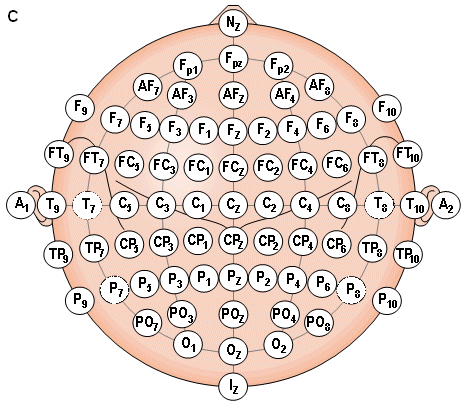


#### EEG Channel Breakdown (Brain Activity)

The EEG channels use a letter-number system where the letter indicates the brain lobe and the number (or 'z') indicates the lateral position.

* **Even numbers (2, 4, 8):** Right hemisphere.
* **Odd numbers (1, 3, 7):** Left hemisphere.
* **'z' (Zero):** Midline.

#### Frontal & Pre-Frontal (Executive Function & Attention)

* **Fp1, Fp2, Fpz:** Pre-frontal (near the forehead). Usually captures eye blinks.
* **F3, F4, F7, F8, Fz:** Frontal lobes. Involved in motor function and high-level cognitive processing.

#### Central & Parietal (Motor & Sensory Integration)

* **C3, C4, Cz:** Central strip. Primary motor and sensory cortex.
* **P3, P4, Pz:** Parietal lobes. Spatial awareness and navigation.

#### Temporal (Auditory & Language)

* **T3, T4, T5, T6 (also labeled T1, T2):** Temporal lobes. Processing sensory input and language.

#### Occipital (Visual Processing)

* **O1, O2:** Located at the back of the head. Primary visual cortex.

#### Reference/Ear

* **A1, A2:** Earlobes (commonly used as reference or ground points).


#### Auxiliary & Peripheral Channels

These channels monitor the body's physical state, which is crucial for "de-noising" the EEG (identifying artifacts) and clinical diagnosis.

| Channel Group | Labels | Description |
| --- | --- | --- |
| **EKG / ECG** | `EKGL`, `EKGR` | **Electrocardiogram**: Monitors heart rate and rhythm. |
| **EOG** | `LOC1`, `LOC2` | **Electrooculogram**: Monitors eye movements (Left/Right Outer Canthus). Used to remove eye-movement noise from EEG. |
| **EMG** | `EMG1`, `EMG2` | **Electromyogram**: Monitors muscle tension, usually in the jaw or neck. |
| **DC / Analog** | `DC1` - `DC4` | Direct Current inputs. Often used for external triggers or synchronized experimental events. |
| **Oximetry** | `OSAT`, `PR` | **Oxygen Saturation** and **Pulse Rate**. Monitors blood oxygen levels and heart rate via a finger clip. |
| **Miscellaneous** | `X9` - `X18` | System-specific auxiliary channels, often used for respiration belts or additional sensors. |

In [221]:
raw_montage_referenced = {}

In [222]:
# set montage and channel types for all datasets
for freq in dbs_freq:
    raw_montage_referenced[freq] = {}
    for state in states:
        print(f"\nConfiguring Raw object for {state} at {freq} Hz DBS...")
        raw_montage_referenced[freq][state] = raw_data[freq][state].copy()
        set_custom_channel_types(raw_montage_referenced[freq][state])
        set_eeg_montage(raw_montage_referenced[freq][state])
        set_reference(raw_montage_referenced[freq][state], ref_channels='average')


Configuring Raw object for SLEEP at 7 Hz DBS...
✅ Successfully mapped 46 channels.
🔄 Renamed legacy channels: {'T1': 'FT9', 'T2': 'FT10'}
✅ Montage applied using 10-05 coordinate system.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
✅ Re-referenced to: average

Configuring Raw object for AWAKE at 7 Hz DBS...
✅ Successfully mapped 46 channels.
🔄 Renamed legacy channels: {'T1': 'FT9', 'T2': 'FT10'}
✅ Montage applied using 10-05 coordinate system.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
✅ Re-referenced to: average

Configuring Raw object for SLEEP at 60 Hz DBS...
✅ Successfully mapped 46 channels.
🔄 Renamed legacy channels: {'T1': 'FT9', 'T2': 'FT10'}
✅ Montage applied using 10-05 coordinate system.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
✅ Re-referenced to: average

Configuring Raw o

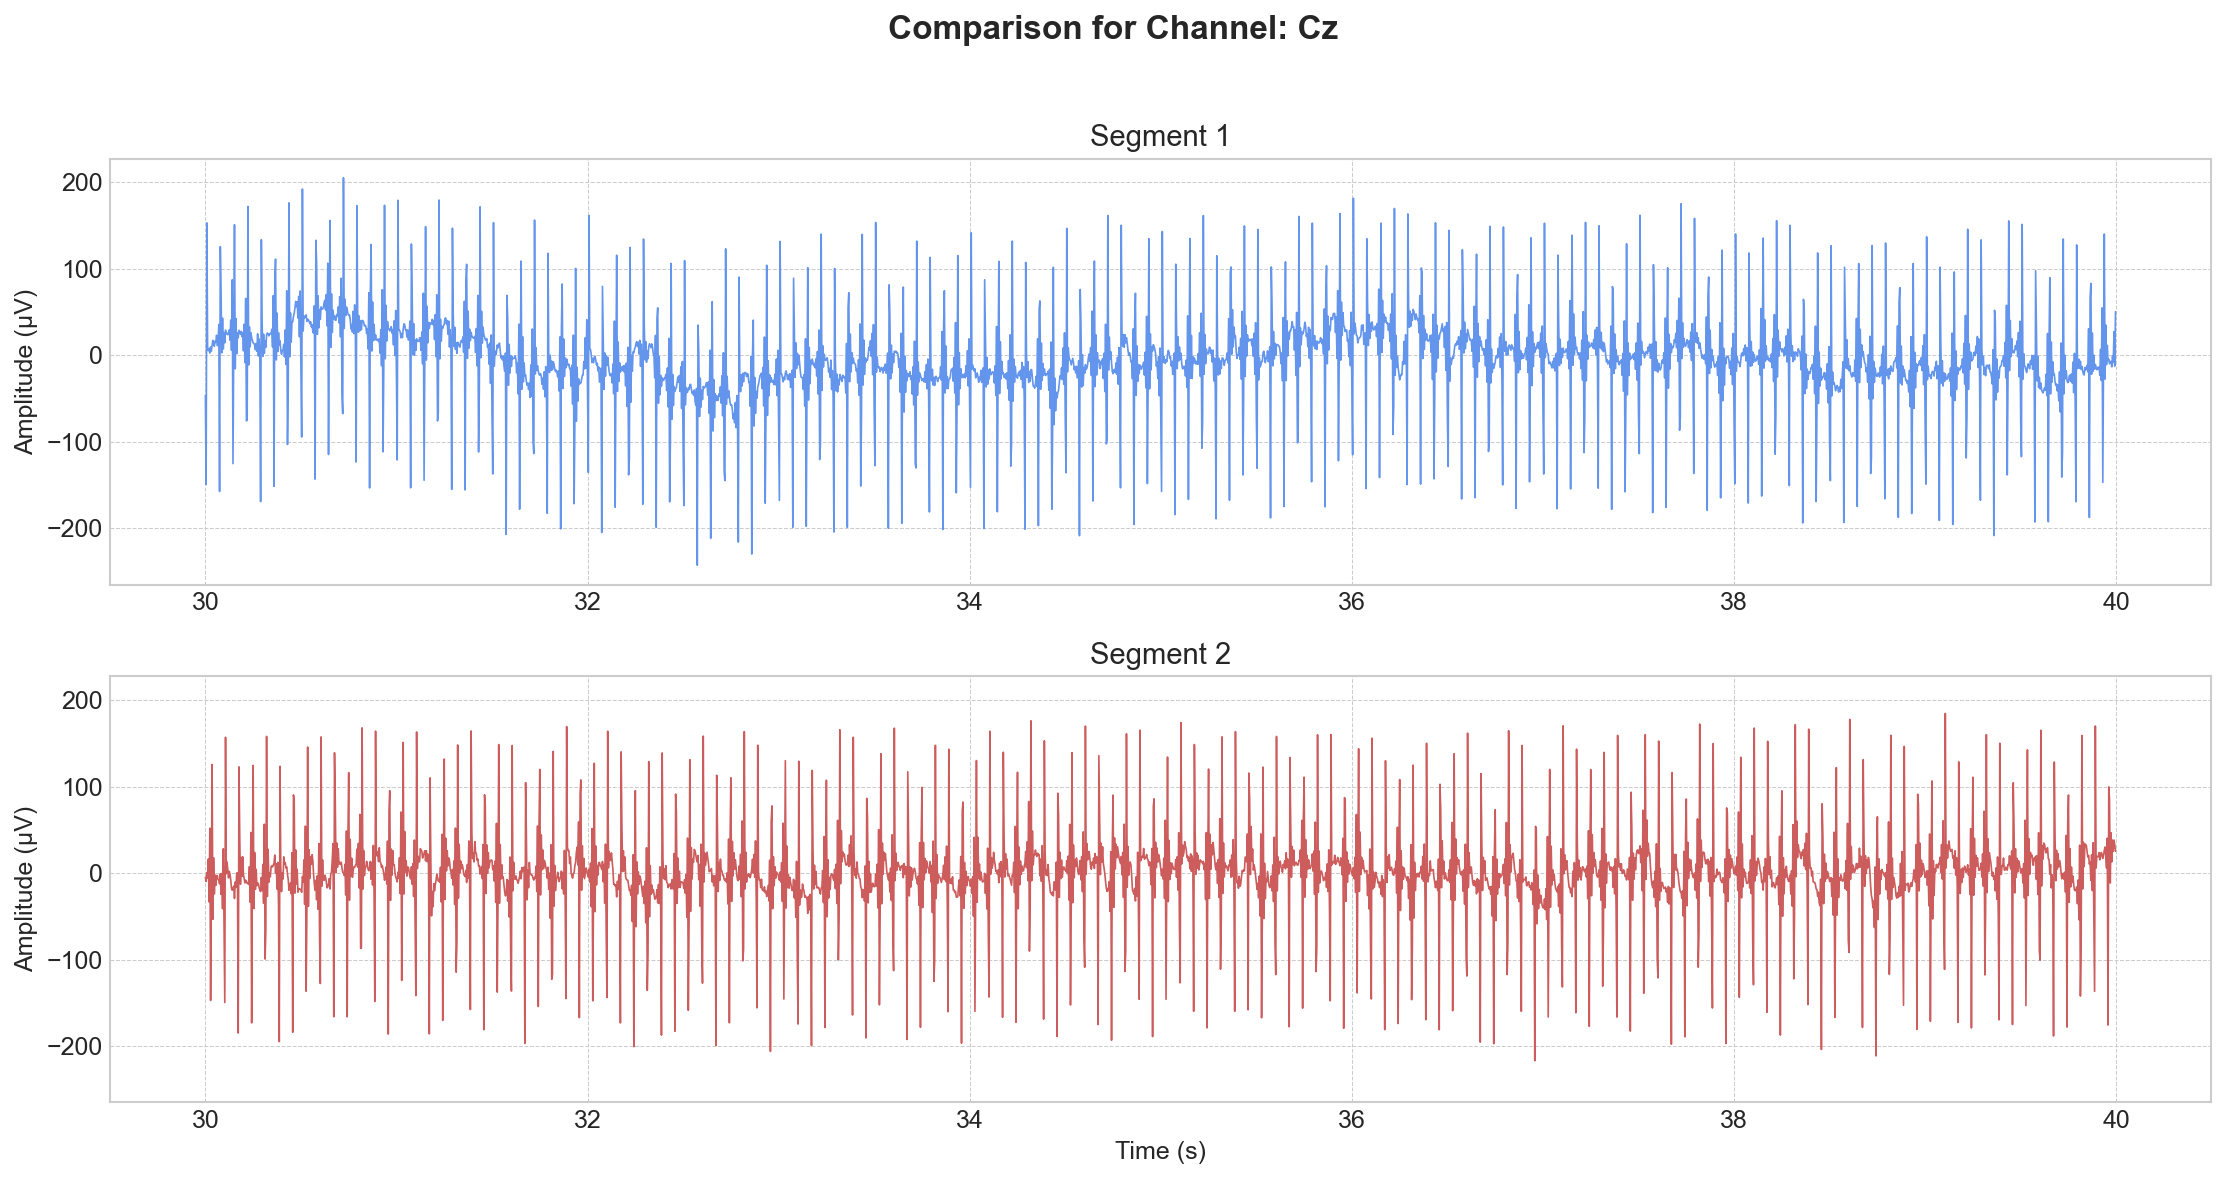

Saved: ../figures/time_domain_comparisons/XU_AWAKE_DBS7_Cz_comparison.png


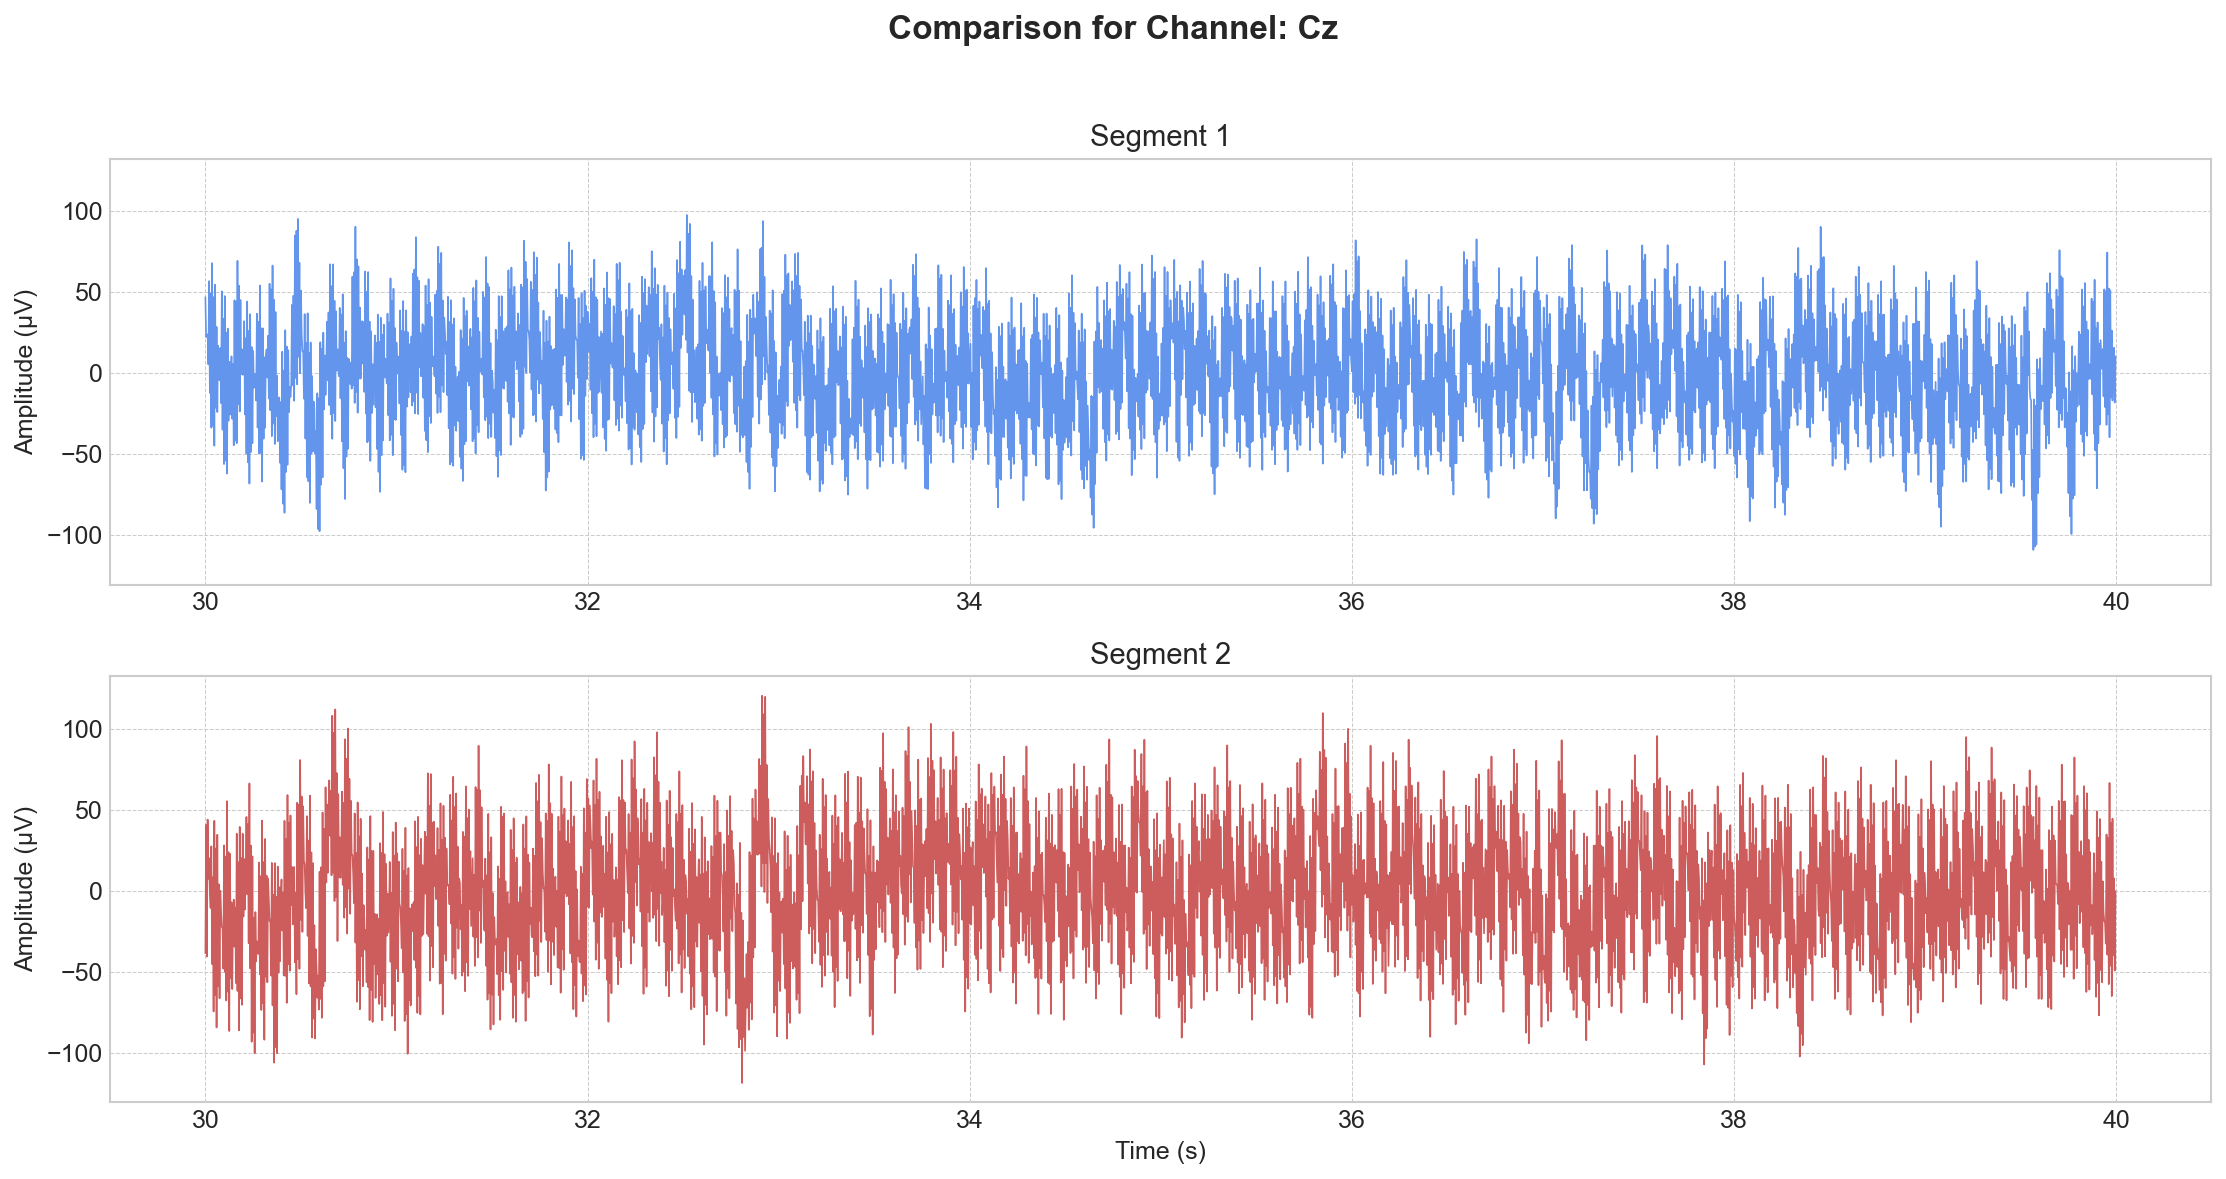

Saved: ../figures/time_domain_comparisons/XU_AWAKE_DBS60_Cz_comparison.png


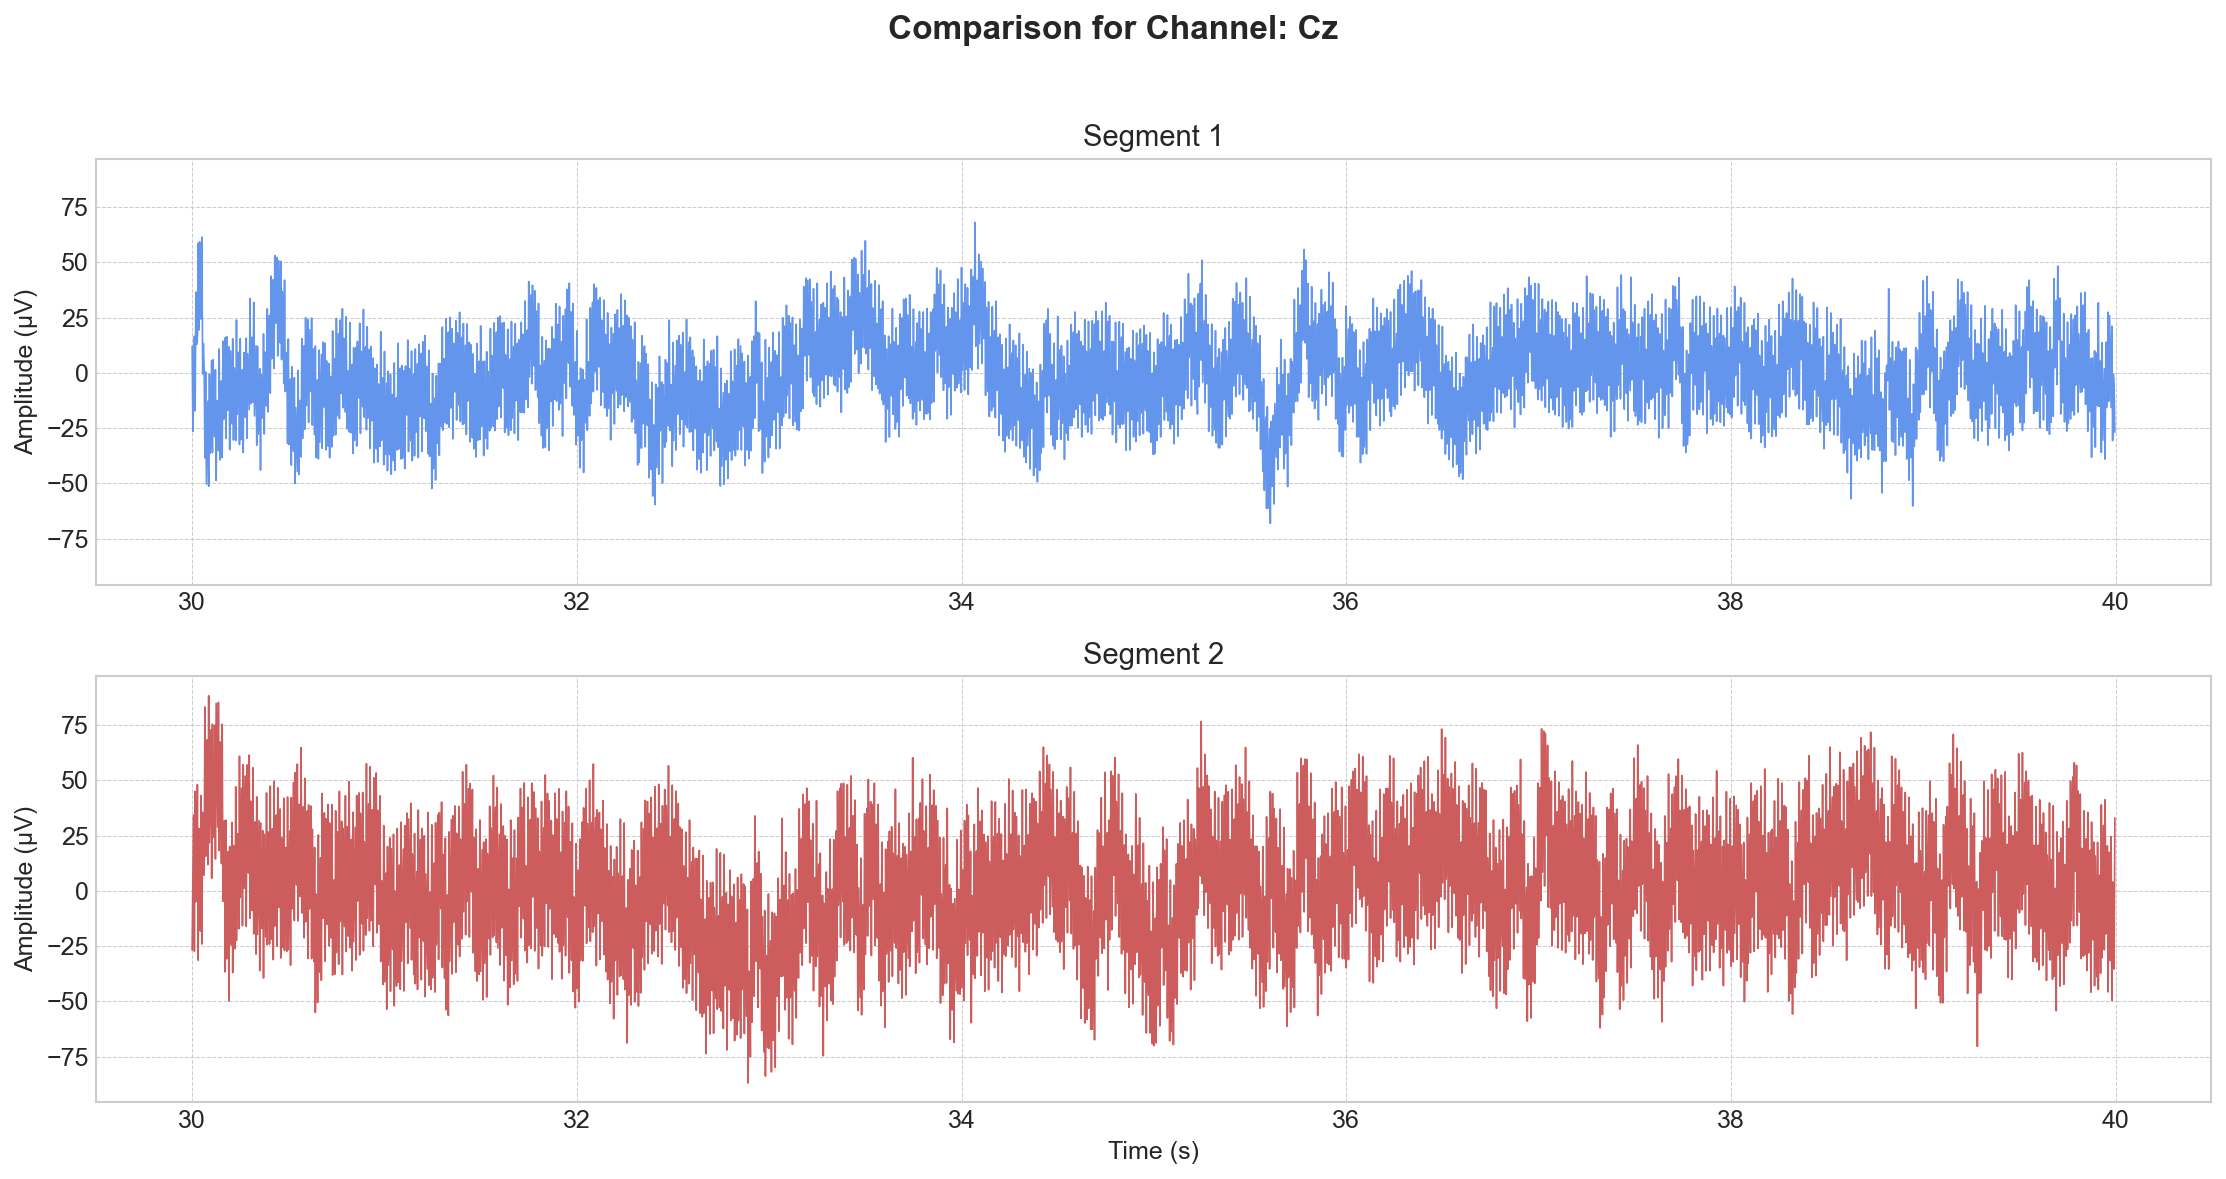

Saved: ../figures/time_domain_comparisons/XU_AWAKE_DBS100_Cz_comparison.png


In [ ]:
# plot and save a time series comparison for Cz channel for all in a ../figures/ folder
for freq in dbs_freq:
    raw_sleep = raw_montage_referenced[freq]['SLEEP']
    raw_awake = raw_montage_referenced[freq]['AWAKE']
    # have a subfolder to keep things organized by type of figure
    folder = f"../figures/time_domain_comparisons/"
    os.makedirs(folder, exist_ok=True)
    fname = f"{folder}{patient}_{state}_DBS{freq}_Cz_comparison.png"
    try:
        fig = save_time_domain_comparison(
            raw_sleep, start1=30,
            raw2=raw_awake, start2=30,
            channel_name='Cz', duration=10, fname=fname
        )
    except TypeError:
        # Fallback: plot_channel_comparison has no `show` argument
        fig = plot_channel_comparison(
            raw_sleep, start1=30,
            raw2=raw_awake, start2=30,
            channel_name='Cz', duration=10
        )
        save_matplotlib_fig(fig, fname)

## Baseline preprocessing and artifact removal

In [157]:
psds_raw = {}
for state in states:
    for freq in dbs_freq:
        print(f"Computed PSD for {state} at {freq} Hz DBS.")
        raw_sleep, raw_awake = raw_data[(state, freq)]
        psds_raw[(state, freq)] = get_psd(raw_sleep,0.5,128), get_psd(raw_awake,0.5,128)

Computed PSD for SLEEP at 7 Hz DBS.
Effective window size : 8.000 (s)
Effective window size : 8.000 (s)
Computed PSD for SLEEP at 60 Hz DBS.
Effective window size : 8.000 (s)
Effective window size : 8.000 (s)
Computed PSD for SLEEP at 100 Hz DBS.
Effective window size : 8.000 (s)
Effective window size : 8.000 (s)
Computed PSD for AWAKE at 7 Hz DBS.
Effective window size : 8.000 (s)
Effective window size : 8.000 (s)
Computed PSD for AWAKE at 60 Hz DBS.
Effective window size : 8.000 (s)
Effective window size : 8.000 (s)
Computed PSD for AWAKE at 100 Hz DBS.
Effective window size : 8.000 (s)
Effective window size : 8.000 (s)


In [158]:
def baseline_preprocessing(raw, l_freq=0.5, h_freq=120.0, powerline_freq=60.0):
    """
    Applies standard montage, average reference, and initial frequency filters.
    """
    raw_bp = raw.copy()
    
    # Standardize spatial map
    montage = mne.channels.make_standard_montage('standard_1020')
    raw_bp.set_montage(montage, on_missing='warn')
    raw_bp.set_eeg_reference('average')
    
    # Bandpass and Notch for powerline
    raw_bp.filter(l_freq=l_freq, h_freq=h_freq, fir_design='firwin', verbose=False)
    if powerline_freq:
        raw_bp.notch_filter(freqs=powerline_freq, fir_design='firwin', verbose=False)
        
    # low pass at 60 Hz to remove high-frequency DBS artifacts while preserving gamma
    raw_bp.filter(l_freq=None, h_freq=60.0, fir_design='firwin', verbose=False)
        
    return raw_bp

# --- VISUALIZATION ---
# Plot raw vs baseline filtered PSD to ensure neural oscillations aren't attenuated
# (Assuming `get_psd` and `plot_psd_comparison` from your helper functions are loaded)
# psd_raw_freqs, psd_raw = get_psd(raw_sleep, fmax=120.0)
# psd_base_freqs, psd_base = get_psd(filtered_baseline, fmax=120.0)
# plot_psd_comparison(psd_raw_freqs, psd_raw[ch_idx], 'Cz', freqs_down=psd_base_freqs, psd_down=psd_base[ch_idx])

In [159]:
psds_baseline = {}
for state in states:
    for freq in dbs_freq:
        print(f"Applied baseline preprocessing and computed PSD for {state} at {freq} Hz DBS.")
        raw_sleep, raw_awake = raw_data[(state, freq)]
        filtered_baseline_sleep = baseline_preprocessing(raw_sleep)
        filtered_baseline_awake = baseline_preprocessing(raw_awake)
        psds_baseline[(state, freq)] = get_psd(filtered_baseline_sleep,0.5,128), get_psd(filtered_baseline_awake,0.5,128)

Applied baseline preprocessing and computed PSD for SLEEP at 7 Hz DBS.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Effective window size : 8.000 (s)
Effective window size : 8.000 (s)
Applied baseline preprocessing and computed PSD for SLEEP at 60 Hz DBS.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Effective window size : 8.000 (s)
Effective window size : 8.000 (s)
Applied baseline preprocessing and computed PSD for SLEEP at 100 Hz DBS.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('

In [160]:
# plot psd comparison for all conditions and save
for state in states:
    for freq in dbs_freq:
        folder = f"../figures/psd_comparisons/"
        os.makedirs(folder, exist_ok=True)
        fname = f"{folder}{patient}_{state}_DBS{freq}_PSD_comparison.png"
        psd_raw_freqs, psd_raw = psds_raw[(state, freq)]
        psd_base_freqs, psd_base = psds_baseline[(state, freq)]
        (freqs_raw_sleep, psd_raw_sleep), (freqs_raw_awake, psd_raw_awake) = psds_raw[(state, freq)]
        (freqs_base_sleep, psd_base_sleep), (freqs_base_awake, psd_base_awake) = psds_baseline[(state, freq)]
        raw_sleep_obj, raw_awake_obj = raw_data[(state, freq)]

        if state == 'SLEEP':
            ch_idx = raw_sleep_obj.ch_names.index('Cz')
            save_psd_raw_vs_filtered(
            freqs_raw_sleep, psd_raw_sleep,
            freqs_base_sleep, psd_base_sleep,
            ch_idx=ch_idx, channel_name='Cz', fname=fname,
            max_freq=128,
            title = f"{patient} {state} DBS{freq} Hz: Raw vs Baseline Filtered PSD"
            )
        else:
            ch_idx = raw_awake_obj.ch_names.index('Cz')
            save_psd_raw_vs_filtered(
            freqs_raw_awake, psd_raw_awake,
            freqs_base_awake, psd_base_awake,
            ch_idx=ch_idx, channel_name='Cz', fname=fname,
            max_freq=128,
            title = f"{patient} {state} DBS{freq} Hz: Raw vs Baseline Filtered PSD"
            )

Saved: ../figures/psd_comparisons/XU_SLEEP_DBS7_PSD_comparison.png
Saved: ../figures/psd_comparisons/XU_SLEEP_DBS60_PSD_comparison.png
Saved: ../figures/psd_comparisons/XU_SLEEP_DBS100_PSD_comparison.png
Saved: ../figures/psd_comparisons/XU_AWAKE_DBS7_PSD_comparison.png
Saved: ../figures/psd_comparisons/XU_AWAKE_DBS60_PSD_comparison.png
Saved: ../figures/psd_comparisons/XU_AWAKE_DBS100_PSD_comparison.png


## Filter suite
Zapline+ is a powerful tool for removing line noise and its harmonics from EEG data. It uses a combination of notch filtering and spatial filtering to effectively clean the data while preserving neural signals.

Spectrum-fit multi-harmonic notch filtering is a technique that identifies and removes specific frequency components (like 50/60 Hz line noise) and their harmonics from the EEG signal. This method is particularly effective in preserving the integrity of the underlying neural signals while eliminating unwanted noise.

Freq-domain hampel filtering is a robust method for identifying and removing outliers in the frequency domain. It works by analyzing the power spectral density (PSD) of the EEG signal and applying a Hampel filter to detect and mitigate the influence of artifacts, such as those caused by DBS, while preserving the true neural oscillations.

Time-domain hampel filtering is a technique that identifies and removes outliers in the time domain. It is particularly useful for detecting transient artifacts, such as those caused by muscle movements or eye blinks, by analyzing the raw EEG signal and applying a Hampel filter to mitigate their impact on the data.

In [162]:
def apply_time_domain_hampel(raw, window_size=101, n_sigmas=3.0):
    """
    Applies a time-domain Hampel filter to suppress high-amplitude DBS spikes.
    Operates via rolling median and Median Absolute Deviation (MAD).
    """
    raw_hampel = raw.copy()
    data = raw_hampel.get_data()
    n_channels, n_samples = data.shape
    
    print(f"Applying Time-Domain Hampel Filter (window={window_size}, sigma={n_sigmas})...")
    
    for ch_idx in range(n_channels):
        channel_data = data[ch_idx, :]
        series = pd.Series(channel_data)
        
        # Calculate rolling median
        rolling_median = series.rolling(window=window_size, center=True).median()
        
        # Calculate Median Absolute Deviation (MAD)
        rolling_mad = series.rolling(window=window_size, center=True).apply(
            lambda x: np.median(np.abs(x - np.median(x))), raw=True
        )
        
        # Edge handling
        rolling_median = rolling_median.bfill().ffill()
        rolling_mad = rolling_mad.bfill().ffill()
        
        # 1.4826 scales MAD to be consistent with standard deviation for normal distributions
        threshold = n_sigmas * 1.4826 * rolling_mad
        
        # Mask and replace outliers
        difference = np.abs(channel_data - rolling_median)
        outlier_mask = difference > threshold
        
        channel_data_filtered = channel_data.copy()
        channel_data_filtered[outlier_mask] = rolling_median[outlier_mask]
        data[ch_idx, :] = channel_data_filtered
        
    # Safely overwrite data in the MNE object
    raw_hampel._data = data 
    return raw_hampel

In [163]:
def apply_freq_domain_hampel(raw, window_size=101, n_sigmas=3.0):
    """
    Applies a Hampel filter to the magnitude spectrum (FFT) of the signal.
    Targets unnatural spectral peaks (like DBS harmonics) while leaving phase intact.
    """
    raw_hampel = raw.copy()
    data = raw_hampel.get_data()
    n_channels, n_samples = data.shape
    
    print(f"Applying Frequency-Domain Hampel Filter (window={window_size}, sigma={n_sigmas})...")
    
    for ch_idx in range(n_channels):
        channel_data = data[ch_idx, :]
        
        # 1. Transform to frequency domain
        fft_coeffs = np.fft.rfft(channel_data)
        magnitude = np.abs(fft_coeffs)
        phase = np.angle(fft_coeffs)
        
        mag_series = pd.Series(magnitude)
        
        # 2. Rolling statistics on the magnitude spectrum
        rolling_median = mag_series.rolling(window=window_size, center=True).median().bfill().ffill()
        rolling_mad = mag_series.rolling(window=window_size, center=True).apply(
            lambda x: np.median(np.abs(x - np.median(x))), raw=True
        ).bfill().ffill()
        
        threshold = n_sigmas * 1.4826 * rolling_mad
        
        # 3. Detect and suppress spectral outliers
        difference = np.abs(magnitude - rolling_median)
        outlier_mask = difference > threshold
        
        magnitude_filtered = magnitude.copy()
        magnitude_filtered[outlier_mask] = rolling_median[outlier_mask]
        
        # 4. Reconstruct complex signal and inverse FFT
        fft_filtered = magnitude_filtered * np.exp(1j * phase)
        data[ch_idx, :] = np.fft.irfft(fft_filtered, n=n_samples)
        
    raw_hampel._data = data
    return raw_hampel

In [169]:
from scipy.linalg import eigh

def apply_zapline_to_raw(raw, line_freqs, n_components=1, verbose=False):
    """
    Robust Zapline-like spatial filtering using GEVD with covariance regularization.
    Returns: (raw_clean, eigenvalues, details, line_freqs)
    """
    if verbose:
        print(f"Applying Zapline Spatial Filter. Targeting: {line_freqs} Hz")

    raw_clean = raw.copy()
    full_data = raw_clean.get_data()  # all channels
    sfreq = raw.info['sfreq']

    # Use EEG channels only for spatial decomposition
    eeg_picks = mne.pick_types(raw.info, eeg=True, exclude='bads')
    if len(eeg_picks) == 0:
        raise ValueError("No EEG channels found for Zapline filtering.")

    data = full_data[eeg_picks, :]
    noise_data = np.zeros_like(data)

    # Build narrowband artifact estimate around each target frequency
    for f in np.atleast_1d(line_freqs):
        lo = max(0.1, float(f) - 0.5)
        hi = min((sfreq / 2) - 0.1, float(f) + 0.5)
        if lo >= hi:
            continue
        tmp = raw.copy().filter(l_freq=lo, h_freq=hi, fir_design='firwin', verbose=False)
        noise_data += tmp.get_data(picks=eeg_picks)

    # Covariance matrices (symmetrized)
    C0 = np.cov(data)
    C1 = np.cov(noise_data)
    C0 = 0.5 * (C0 + C0.T)
    C1 = 0.5 * (C1 + C1.T)

    n_ch = C0.shape[0]
    I = np.eye(n_ch)
    scale = np.trace(C0) / max(n_ch, 1)
    reg_grid = [1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4]

    eigvals = eigvecs = None
    used_reg = None

    # Try progressively stronger regularization until GEVD succeeds
    for r in reg_grid:
        reg = max(scale * r, 1e-15)
        try:
            eigvals, eigvecs = eigh(C1 + reg * I, C0 + reg * I, check_finite=False)
            used_reg = reg
            break
        except Exception:
            continue

    if eigvals is None or eigvecs is None:
        raise RuntimeError("GEVD failed even after regularization.")

    # Sort by descending artifact dominance
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # Artifact subspace
    n_components = int(max(1, min(n_components, n_ch - 1)))
    W_artifact = eigvecs[:, :n_components]

    # Projector: P = I - W (W^T C0 W)^-1 W^T C0
    G = W_artifact.T @ C0 @ W_artifact
    G += 1e-12 * np.eye(G.shape[0])  # numerical safety
    P = I - W_artifact @ np.linalg.pinv(G) @ W_artifact.T @ C0

    cleaned_eeg = P @ data

    # Put cleaned EEG back; non-EEG channels untouched
    full_data[eeg_picks, :] = cleaned_eeg
    raw_clean._data = full_data

    details = {"used_regularization": used_reg, "n_eeg_channels": len(eeg_picks)}
    return raw_clean, eigvals, details, np.atleast_1d(line_freqs)

In [165]:
def execute_filter_suite(raw_baseline, dbs_freq, powerline_freq=60.0):
    """
    Executes the four advanced filtering methods for artifact removal.
    """
    sfreq = raw_baseline.info['sfreq']
    dbs_harmonics = np.arange(dbs_freq, sfreq / 2, dbs_freq)
    pl_harmonics = np.arange(powerline_freq, sfreq / 2, powerline_freq)
    all_artifacts = np.union1d(dbs_harmonics, pl_harmonics)
    
    suite_results = {}
    
    # 1. Zapline+ (Spatial-Spectral)
    print("Running Zapline+...")
    zapline_raw, _, _, _ = apply_zapline_to_raw(raw_baseline.copy(), line_freqs=dbs_harmonics, verbose=False)
    suite_results['Zapline+'] = zapline_raw
    
    # 2. Spectrum-Fit Multi-Harmonic
    print("Running Spectrum-Fit...")
    spec_raw = raw_baseline.copy().notch_filter(freqs=all_artifacts, method='spectrum_fit', verbose=False)
    suite_results['Spectrum-Fit'] = spec_raw
    
    # 3. Freq-Domain Hampel (Allen et al., 2010 style)
    print("Running Freq-Domain Hampel...")
    # Assuming apply_freq_domain_hampel is loaded from your previous cells
    freq_hampel_raw = apply_freq_domain_hampel(raw_baseline.copy(), window_size=101, n_sigmas=3)
    suite_results['Freq-Hampel'] = freq_hampel_raw
    
    # 4. Time-Domain Hampel
    print("Running Time-Domain Hampel...")
    time_hampel_raw = apply_time_domain_hampel(raw_baseline.copy(), window_size=int(0.2 * sfreq), n_sigmas=3)
    suite_results['Time-Hampel'] = time_hampel_raw
    
    return suite_results

## Temporal Template Subtraction
Temporal Template Subtraction is a method for removing artifacts by creating a template of the artifact and subtracting it from the EEG signal. This technique is particularly effective for repetitive artifacts, such as those caused by DBS, where the artifact has a consistent shape and timing.

In [170]:
from scipy.signal import find_peaks

def temporal_template_subtraction(raw, dbs_freq, target_channel='Cz'):
    """
    Identifies DBS pulses, builds an average temporal template, and subtracts it.
    """
    raw_clean = raw.copy()
    data = raw_clean.get_data()
    sfreq = raw.info['sfreq']
    ch_idx = raw.ch_names.index(target_channel)
    
    print(f"Building Temporal Template aligned to {dbs_freq}Hz on {target_channel}...")
    
    # 1. Detect DBS Peaks (Synthetic Triggers)
    # Distance is roughly the sampling rate divided by the DBS frequency
    expected_distance = int((sfreq / dbs_freq) * 0.8) 
    peaks, _ = find_peaks(data[ch_idx], distance=expected_distance, prominence=np.std(data[ch_idx]))
    
    # Create MNE events array: [sample_index, 0, event_id]
    events = np.column_stack((peaks, np.zeros_like(peaks), np.ones_like(peaks)))
    
    # 2. Epoch around the peaks to capture the artifact morphology
    # Window size covers one full DBS cycle
    t_window = 1.0 / dbs_freq 
    tmin, tmax = -(t_window / 2), (t_window / 2)
    
    epochs = mne.Epochs(raw_clean, events, event_id=1, tmin=tmin, tmax=tmax, baseline=None, preload=True, verbose=False)
    
    # 3. Create the Template (The Evoked Average)
    template_evoked = epochs.average()
    template_data = template_evoked.data # Shape: (n_channels, n_times)
    
    # 4. Subtract the Template from the continuous data
    print("Subtracting template from continuous recording...")
    window_samples = template_data.shape[1]
    half_window = window_samples // 2
    
    for peak in peaks:
        start_idx = peak - half_window
        end_idx = start_idx + window_samples
        
        # Ensure we don't go out of bounds at the edges of the recording
        if start_idx >= 0 and end_idx <= data.shape[1]:
            # Subtract the template channel by channel
            data[:, start_idx:end_idx] -= template_data
            
    raw_clean._data = data
    
    # Plot the template for verification
    fig = template_evoked.plot(titles="DBS Artifact Template", show=False)
    plt.show()
    
    return raw_clean

In [175]:
raw_data

{('SLEEP',
  7): (<RawEDF | XUSLEEP7.EDF, 46 x 163328 (638.0 s), ~57.4 MiB, data loaded>, <RawEDF | XUAWAKE7.EDF, 46 x 145408 (568.0 s), ~51.1 MiB, data loaded>),
 ('SLEEP',
  60): (<RawEDF | XUSLEEP60.EDF, 46 x 165376 (646.0 s), ~58.1 MiB, data loaded>, <RawEDF | XUAWAKE60.EDF, 46 x 156160 (610.0 s), ~54.9 MiB, data loaded>),
 ('SLEEP',
  100): (<RawEDF | XUSLEEP100.EDF, 46 x 155136 (606.0 s), ~54.5 MiB, data loaded>, <RawEDF | XUAWAKE100.EDF, 46 x 163328 (638.0 s), ~57.4 MiB, data loaded>),
 ('AWAKE',
  7): (<RawEDF | XUSLEEP7.EDF, 46 x 163328 (638.0 s), ~57.4 MiB, data loaded>, <RawEDF | XUAWAKE7.EDF, 46 x 145408 (568.0 s), ~51.1 MiB, data loaded>),
 ('AWAKE',
  60): (<RawEDF | XUSLEEP60.EDF, 46 x 165376 (646.0 s), ~58.1 MiB, data loaded>, <RawEDF | XUAWAKE60.EDF, 46 x 156160 (610.0 s), ~54.9 MiB, data loaded>),
 ('AWAKE',
  100): (<RawEDF | XUSLEEP100.EDF, 46 x 155136 (606.0 s), ~54.5 MiB, data loaded>, <RawEDF | XUAWAKE100.EDF, 46 x 163328 (638.0 s), ~57.4 MiB, data loaded>)}

In [174]:
filter_suite_results = {}
for state in tqdm.tqdm(states, desc="States"):
    for freq in tqdm.tqdm(dbs_freq, desc="DBS Frequencies", leave=False):
        print(f"\nExecuting filter suite for {state} at {freq} Hz DBS...")
        raw_sleep, raw_awake = raw_data[(state, freq)]
        filtered_baseline_sleep = baseline_preprocessing(raw_sleep)
        filtered_baseline_awake = baseline_preprocessing(raw_awake)
        
        # Run the advanced filter suite on the baseline-filtered data
        suite_sleep = execute_filter_suite(filtered_baseline_sleep, dbs_freq=freq)
        suite_awake = execute_filter_suite(filtered_baseline_awake, dbs_freq=freq)
        
        filter_suite_results[(state, freq)] = (suite_sleep, suite_awake)
        print(f"Completed filter suite for {state} at {freq} Hz DBS.")

States:   0%|          | 0/2 [00:00<?, ?it/s]


Executing filter suite for SLEEP at 7 Hz DBS...
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Running Zapline+...
Running Spectrum-Fit...
Running Freq-Domain Hampel...
Applying Frequency-Domain Hampel Filter (window=101, sigma=3)...
Running Time-Domain Hampel...
Applying Time-Domain Hampel Filter (window=51, sigma=3)...
Running Zapline+...
Running Spectrum-Fit...
Running Freq-Domain Hampel...
Applying Frequency-Domain Hampel Filter (window=101, sigma=3)...
Running Time-Domain Hampel...
Applying Time-Domain Hampel Filter (window=51, sigma=3)...


Completed filter suite for SLEEP at 7 Hz DBS.

Executing filter suite for SLEEP at 60 Hz DBS...
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Running Zapline+...
Running Spectrum-Fit...
Running Freq-Domain Hampel...
Applying Frequency-Domain Hampel Filter (window=101, sigma=3)...
Running Time-Domain Hampel...
Applying Time-Domain Hampel Filter (window=51, sigma=3)...
Running Zapline+...
Running Spectrum-Fit...
Running Freq-Domain Hampel...
Applying Frequency-Domain Hampel Filter (window=101, sigma=3)...
Running Time-Domain Hampel...
Applying Time-Domain Hampel Filter (window=51, sigma=3)...


Completed filter suite for SLEEP at 60 Hz DBS.

Executing filter suite for SLEEP at 100 Hz DBS...
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Running Zapline+...
Running Spectrum-Fit...
Running Freq-Domain Hampel...
Applying Frequency-Domain Hampel Filter (window=101, sigma=3)...
Running Time-Domain Hampel...
Applying Time-Domain Hampel Filter (window=51, sigma=3)...
Running Zapline+...
Running Spectrum-Fit...
Running Freq-Domain Hampel...
Applying Frequency-Domain Hampel Filter (window=101, sigma=3)...
Running Time-Domain Hampel...
Applying Time-Domain Hampel Filter (window=51, sigma=3)...


States:  50%|█████     | 1/2 [48:38<48:38, 2918.13s/it]

Completed filter suite for SLEEP at 100 Hz DBS.



Executing filter suite for AWAKE at 7 Hz DBS...
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Running Zapline+...
Running Spectrum-Fit...
Running Freq-Domain Hampel...
Applying Frequency-Domain Hampel Filter (window=101, sigma=3)...
Running Time-Domain Hampel...
Applying Time-Domain Hampel Filter (window=51, sigma=3)...
Running Zapline+...
Running Spectrum-Fit...
Running Freq-Domain Hampel...
Applying Frequency-Domain Hampel Filter (window=101, sigma=3)...
Running Time-Domain Hampel...
Applying Time-Domain Hampel Filter (window=51, sigma=3)...


Completed filter suite for AWAKE at 7 Hz DBS.

Executing filter suite for AWAKE at 60 Hz DBS...
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Running Zapline+...
Running Spectrum-Fit...
Running Freq-Domain Hampel...
Applying Frequency-Domain Hampel Filter (window=101, sigma=3)...


States:  50%|█████     | 1/2 [1:03:31<1:03:31, 3811.71s/it]


KeyboardInterrupt: 

In [ ]:
temporal_template_subtraction_results = {}
for state in states:
    for freq in dbs_freq:
        print(f"\nApplying Temporal Template Subtraction for {state} at {freq} Hz DBS...")
        raw_sleep, raw_awake = raw_data[(state, freq)]
        filtered_baseline_sleep = baseline_preprocessing(raw_sleep)
        filtered_baseline_awake = baseline_preprocessing(raw_awake)
        
        tts_sleep = temporal_template_subtraction(filtered_baseline_sleep, dbs_freq=freq, target_channel='Cz')
        tts_awake = temporal_template_subtraction(filtered_baseline_awake, dbs_freq=freq, target_channel='Cz')
        
        temporal_template_subtraction_results[(state, freq)] = (tts_sleep, tts_awake)